In [1]:
import numpy as np

# (Nbls, Ntimes, Nfreq, Npol)=(1,1600,600,1)

# EoR only
d_eor = np.load("generate_data/eor_data.npz", allow_pickle=True)
eor_data_raw = d_eor["data"]
freqs_eor = d_eor["freqs"]   # unit MHz
times_eor = d_eor["times"]

# EoR + foreground
d_fg = np.load("generate_data/eor_fg_data.npz", allow_pickle=True)
eor_fg_data_raw = d_fg["data"]

# EoR + foreground + noise
d_efn = np.load("generate_data/eor_fg_noise.npz", allow_pickle=True)
eor_fg_noise_raw = d_efn["data"]

# Thermal noise
d_noise = np.load("generate_data/noise.npz", allow_pickle=True)
noise_raw = d_noise["noise"]
noise_var_raw = d_noise["noise_var"]


# Flags
d_flag = np.load("generate_data/flags.npz", allow_pickle=True)
flags_raw = d_flag["flags"]

# Check original shapes
print("Original shapes")
print("eor_data_raw      :", eor_data_raw.shape)
print("eor_fg_data_raw   :", eor_fg_data_raw.shape)
print("eor_fg_noise_raw  :", eor_fg_noise_raw.shape)
print("noise_raw         :", noise_raw.shape)
print("noise_var_raw     :", noise_var_raw.shape)
print("flags_raw         :", flags_raw.shape)




Original shapes
eor_data_raw      : (1, 1600, 600, 1)
eor_fg_data_raw   : (1, 1600, 600, 1)
eor_fg_noise_raw  : (1, 1600, 600, 1)
noise_raw         : (1, 1600, 600, 1)
noise_var_raw     : (1, 1600, 600, 1)
flags_raw         : (1, 1600, 600, 1)


# cut part

In [2]:
# (1, 1600, 600, 1) -> (1, 20, 180, 1)

eor_data_raw      = eor_data_raw[:, :20, :, :]
eor_fg_data_raw   = eor_fg_data_raw[:, :20, :, :]
eor_fg_noise_raw  = eor_fg_noise_raw[:, :20, :, :]
noise_raw         = noise_raw[:, :20, :, :]
noise_var_raw     = noise_var_raw[:, :20, :, :]
flags_raw         = flags_raw[:, :20, :, :]

# 如果频率数组长度是 600，也同步截取
freqs_eor = freqs_eor[:]

# 如果 times_eor 长度是 1600，也同步截取
times_eor = times_eor[:20]

print("\nTrimmed shapes")
print("eor_data_raw      :", eor_data_raw.shape)
print("eor_fg_data_raw   :", eor_fg_data_raw.shape)
print("eor_fg_noise_raw  :", eor_fg_noise_raw.shape)
print("noise_raw         :", noise_raw.shape)
print("noise_var_raw     :", noise_var_raw.shape)
print("flags_raw         :", flags_raw.shape)


Trimmed shapes
eor_data_raw      : (1, 20, 600, 1)
eor_fg_data_raw   : (1, 20, 600, 1)
eor_fg_noise_raw  : (1, 20, 600, 1)
noise_raw         : (1, 20, 600, 1)
noise_var_raw     : (1, 20, 600, 1)
flags_raw         : (1, 20, 600, 1)


In [3]:
# convert: (Nbls, Ntimes, Nfreq, Npol)
#       -> (Npol, Nbls，Ntimes,  Nfreq)

eor_data     = np.transpose(eor_data_raw,     (3, 0, 1, 2))
eor_fg_data  = np.transpose(eor_fg_data_raw,  (3, 0, 1, 2))
eor_fg_noise = np.transpose(eor_fg_noise_raw, (3, 0, 1, 2))
noise         = np.transpose(noise_raw,        (3, 0, 1, 2))
noise_var     = np.transpose(noise_var_raw,    (3, 0, 1, 2))
flags         = np.transpose(flags_raw,        (3, 0, 1, 2))

# Check converted shapes
print("\nConverted shapes")
print("eor_data      :", eor_data.shape)
print("eor_fg_data   :", eor_fg_data.shape)
print("eor_fg_noise  :", eor_fg_noise.shape)
print("noise         :", noise.shape)
print("noise_var     :", noise_var.shape)
print("flags         :", flags.shape)


Converted shapes
eor_data      : (1, 1, 20, 600)
eor_fg_data   : (1, 1, 20, 600)
eor_fg_noise  : (1, 1, 20, 600)
noise         : (1, 1, 20, 600)
noise_var     : (1, 1, 20, 600)
flags         : (1, 1, 20, 600)


In [4]:
import numpy as np
from matplotlib import pyplot as plt
#d = np.load("/Users/alliswell48/simpleQE/notebooks/generate_datat/gpr_inpaint_input.npz")

#fchans = [(20, 21), (40, 41), (80, 81), (95, 96), (120, 121),[170,171]]

data0 = eor_fg_noise
inp_flags0 = flags 
inv_wgts0 = noise_var
freqs0 = freqs_eor
fg0=eor_fg_data -eor_data 
noise0=noise



inv_wgts0 = inv_wgts0.copy()
inv_wgts0[inp_flags0] = 2e10     # ≫ outputscale(1e3),又 ≪ 1e10


print(data0.shape)
print(inp_flags0.shape)
print(inv_wgts0.shape)
print(freqs0.shape)
print(fg0.shape)
print(noise0.shape)

(1, 1, 20, 600)
(1, 1, 20, 600)
(1, 1, 20, 600)
(600,)
(1, 1, 20, 600)
(1, 1, 20, 600)


In [5]:
import torch

# numpy → torch
data = torch.tensor(data0)
inp_flags = torch.tensor(inp_flags0)
inv_wgts = torch.tensor(inv_wgts0)
freqs = torch.tensor(freqs0)

# 统一 dtype
freqs = freqs.double()               # Hz, float32
data = data.to(torch.complex128)     # complex64
inv_wgts = inv_wgts.double()         # float32
inp_flags = inp_flags.bool()        # bool

# 检查
print("data.shape =", data.shape)
print("inp_flags.shape =", inp_flags.shape)
print("inv_wgts.shape =", inv_wgts.shape)
print("freqs.shape =", freqs.shape)

print("data.dtype =", data.dtype)
print("inp_flags.dtype =", inp_flags.dtype)
print("inv_wgts.dtype =", inv_wgts.dtype)
print("freqs.dtype =", freqs.dtype)

data.shape = torch.Size([1, 1, 20, 600])
inp_flags.shape = torch.Size([1, 1, 20, 600])
inv_wgts.shape = torch.Size([1, 1, 20, 600])
freqs.shape = torch.Size([600])
data.dtype = torch.complex128
inp_flags.dtype = torch.bool
inv_wgts.dtype = torch.float64
freqs.dtype = torch.float64


In [6]:
Nbls, Ntimes, Nfreqs = data.shape[-3:]  #忽律pol 极化维度
train_y = torch.vstack([data.real.reshape(-1, Nfreqs), data.imag.reshape(-1, Nfreqs)])


In [7]:
# per band, per red-group, per-pol inpainting

data   #(Npol,Nbls, Ntimes, Nfreq)=>(1,1, Ntimes, Nfreq)
inv_wgts
inp_flags
freqs
bl_len = 14.6   # meter,HERA baseline, 现在只假设一个固定基线
kernA_var=0.01
center_y=True
Ndeg=1 #polfit
horizon_buffer=150
min_horizon_dly=150
kernA='sinc'   #最外层
kernB='sinc'  #中层
kernB_buffer=200
kernB_max_dly=1000
kernB_rel_var=0.01
kernC='sinc'    #最内层
kernC_buffer=500
kernC_max_dly=1200
kernC_rel_var=0.1

In [8]:
Nfreqs

600

In [9]:
train_xt = freqs[:, None]  # [MHz] Size([3，1])
#freqs[:]=>freqs[:, None].shape 等价于freqs.Size([3])=>freqs.Size([3，1])

train_x = train_xt.expand((1, Nfreqs, 1)) # Size([3，1]) =>Size([1, 3, 1])
inp_flags = torch.vstack([inp_flags.reshape(-1, Nfreqs), inp_flags.reshape(-1, Nfreqs)])
train_wgts = torch.vstack([inv_wgts.reshape(-1, Nfreqs), inv_wgts.reshape(-1, Nfreqs)]) / 2  # real/imag

# tau [ns] to sinc length-scale [MHz]
tau2ls = lambda tau: 1e3 / 2 / tau  # ns
bl_tau = max([bl_len / 2.99792e8 * 1e9 + horizon_buffer, min_horizon_dly])  # ns

In [10]:
# get mean and covar model of 3-sinc mixture

import gprlim
from gprlim import models

print(gprlim.__file__)

mean, covar = models.multi_kernel_mixture(
    mean_fix_constant=True,
    mean_set_constant=0,
    kern2=kernA,
    kern2_set_lengthscale=tau2ls(bl_tau),
    kern2_set_outputscale=kernA_var,
    kern1=kernB,
    kern1_set_lengthscale=tau2ls(min([bl_tau + kernB_buffer, kernB_max_dly])),
    kern1_set_outputscale=kernB_rel_var,
    kern0=kernC,
    kern0_set_lengthscale=tau2ls(min([bl_tau + kernC_buffer, kernC_max_dly])),
    kern0_set_outputscale=kernC_rel_var,
)

/Users/alliswell48/gprlim/gprlim/__init__.py


In [11]:
# get GPModel
model, y_offset = models.fixednoise_gp_1d(
    train_x, train_y, mean, covar, inv_wgts=train_wgts, center_y=center_y, Ndeg=Ndeg,
    
)
y_offset = y_offset if y_offset is not None else 0



In [12]:
y_offset

tensor([[12.6988, 12.6988, 12.6988,  ..., 12.6988, 12.6988, 12.6988],
        [12.8557, 12.8557, 12.8557,  ..., 12.8557, 12.8557, 12.8557],
        [13.1215, 13.1215, 13.1215,  ..., 13.1215, 13.1215, 13.1215],
        ...,
        [16.7579, 16.7579, 16.7579,  ..., 16.7579, 16.7579, 16.7579],
        [16.1763, 16.1763, 16.1763,  ..., 16.1763, 16.1763, 16.1763],
        [16.0418, 16.0418, 16.0418,  ..., 16.0418, 16.0418, 16.0418]],
       dtype=torch.float64)

In [13]:
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    #max_iter=1
)

loss, opt = models.optimize_kernel(
    model,
    Niter=30,
    opt=optimizer,
    thresh=None,
    #thresh=1e-5
)

Iter   1/ 30 Loss=  45.843   outputscale=  0.0100   lengthscale=  2.5164   outputscale=  0.0100   lengthscale=  1.2541   outputscale=  0.1000   lengthscale=  0.7156
Iter   1/ 30 Loss=  45.744   outputscale=  0.0108   lengthscale=  2.5386   outputscale=  0.0100   lengthscale=  1.2542   outputscale=  0.1000   lengthscale=  0.7156
Iter   1/ 30 Loss=  45.562   outputscale=  0.0122   lengthscale=  2.5763   outputscale=  0.0100   lengthscale=  1.2545   outputscale=  0.1000   lengthscale=  0.7156
Iter   1/ 30 Loss=  45.326   outputscale=  0.0140   lengthscale=  2.6206   outputscale=  0.0100   lengthscale=  1.2547   outputscale=  0.1000   lengthscale=  0.7157
Iter   1/ 30 Loss=  45.009   outputscale=  0.0165   lengthscale=  2.6719   outputscale=  0.0100   lengthscale=  1.2551   outputscale=  0.1000   lengthscale=  0.7157
Iter   1/ 30 Loss=  44.567   outputscale=  0.0199   lengthscale=  2.7326   outputscale=  0.0100   lengthscale=  1.2554   outputscale=  0.1000   lengthscale=  0.7157
Iter   1/ 

Iter   3/ 30 Loss=   4.845   outputscale=  9.7669   lengthscale=  5.4437   outputscale=  1.6444   lengthscale=  3.4873   outputscale=  0.1273   lengthscale=  0.8342
Iter   3/ 30 Loss=   4.798   outputscale=  9.9618   lengthscale=  5.4407   outputscale=  1.8652   lengthscale=  3.6401   outputscale=  0.1210   lengthscale=  0.9228
Iter   3/ 30 Loss=   4.765   outputscale= 10.1067   lengthscale=  5.4397   outputscale=  2.0675   lengthscale=  3.6516   outputscale=  0.1165   lengthscale=  0.9872
Iter   3/ 30 Loss=   4.724   outputscale= 10.3069   lengthscale=  5.4378   outputscale=  2.3331   lengthscale=  3.7185   outputscale=  0.1104   lengthscale=  1.1369
Iter   3/ 30 Loss=   4.614   outputscale= 10.9372   lengthscale=  5.4292   outputscale=  3.1640   lengthscale=  4.0770   outputscale=  0.0942   lengthscale=  1.7464
Iter   3/ 30 Loss=   4.594   outputscale= 11.0827   lengthscale=  5.4250   outputscale=  3.3549   lengthscale=  4.1597   outputscale=  0.0940   lengthscale=  1.9114
Iter   3/ 

Iter   6/ 30 Loss=   4.344   outputscale= 17.6821   lengthscale=  5.2428   outputscale= 11.3946   lengthscale=  8.6625   outputscale=  4.2071   lengthscale=  5.4808
Iter   6/ 30 Loss=   4.344   outputscale= 17.6967   lengthscale=  5.2391   outputscale= 11.4110   lengthscale=  8.6781   outputscale=  4.2057   lengthscale=  5.4836
Iter   6/ 30 Loss=   4.344   outputscale= 17.7147   lengthscale=  5.2340   outputscale= 11.4310   lengthscale=  8.6972   outputscale=  4.2037   lengthscale=  5.4868
Iter   6/ 30 Loss=   4.344   outputscale= 17.7372   lengthscale=  5.2271   outputscale= 11.4559   lengthscale=  8.7213   outputscale=  4.2008   lengthscale=  5.4908
Iter   6/ 30 Loss=   4.344   outputscale= 17.7660   lengthscale=  5.2177   outputscale= 11.4878   lengthscale=  8.7521   outputscale=  4.1967   lengthscale=  5.4957
Iter   6/ 30 Loss=   4.344   outputscale= 17.8025   lengthscale=  5.2053   outputscale= 11.5281   lengthscale=  8.7913   outputscale=  4.1910   lengthscale=  5.5019
Iter   6/ 

Iter   8/ 30 Loss=   4.343   outputscale= 18.5878   lengthscale=  5.2394   outputscale= 12.2643   lengthscale=  9.5332   outputscale=  2.8716   lengthscale=  5.4452
Iter   8/ 30 Loss=   4.343   outputscale= 18.5967   lengthscale=  5.2430   outputscale= 12.2721   lengthscale=  9.5331   outputscale=  2.8647   lengthscale=  5.4432
Iter   8/ 30 Loss=   4.343   outputscale= 18.6072   lengthscale=  5.2467   outputscale= 12.2815   lengthscale=  9.5334   outputscale=  2.8581   lengthscale=  5.4411
Iter   8/ 30 Loss=   4.343   outputscale= 18.6195   lengthscale=  5.2506   outputscale= 12.2926   lengthscale=  9.5343   outputscale=  2.8515   lengthscale=  5.4389
Iter   8/ 30 Loss=   4.343   outputscale= 18.6339   lengthscale=  5.2546   outputscale= 12.3059   lengthscale=  9.5358   outputscale=  2.8451   lengthscale=  5.4368
Iter   8/ 30 Loss=   4.343   outputscale= 18.6508   lengthscale=  5.2588   outputscale= 12.3217   lengthscale=  9.5381   outputscale=  2.8387   lengthscale=  5.4346
Iter   8/ 

Iter  11/ 30 Loss=   4.336   outputscale= 38.1697   lengthscale=  5.2969   outputscale= 32.2055   lengthscale=  9.8688   outputscale=  0.0552   lengthscale=  5.2653
Iter  11/ 30 Loss=   4.336   outputscale= 38.3273   lengthscale=  5.2897   outputscale= 32.3720   lengthscale=  9.8596   outputscale=  0.0547   lengthscale=  5.2676
Iter  11/ 30 Loss=   4.336   outputscale= 38.4462   lengthscale=  5.2881   outputscale= 32.4957   lengthscale=  9.8484   outputscale=  0.0540   lengthscale=  5.2685
Iter  11/ 30 Loss=   4.336   outputscale= 38.5566   lengthscale=  5.2859   outputscale= 32.6115   lengthscale=  9.8399   outputscale=  0.0536   lengthscale=  5.2697
Iter  11/ 30 Loss=   4.336   outputscale= 38.6582   lengthscale=  5.2849   outputscale= 32.7180   lengthscale=  9.8314   outputscale=  0.0532   lengthscale=  5.2708
Iter  11/ 30 Loss=   4.336   outputscale= 38.7567   lengthscale=  5.2836   outputscale= 32.8215   lengthscale=  9.8242   outputscale=  0.0529   lengthscale=  5.2720
Iter  11/ 

Iter  13/ 30 Loss=   4.336   outputscale= 40.1343   lengthscale=  5.2801   outputscale= 34.2533   lengthscale=  9.7652   outputscale=  0.0496   lengthscale=  5.2814
Iter  13/ 30 Loss=   4.336   outputscale= 40.1369   lengthscale=  5.2801   outputscale= 34.2559   lengthscale=  9.7653   outputscale=  0.0496   lengthscale=  5.2813
Iter  13/ 30 Loss=   4.336   outputscale= 40.1393   lengthscale=  5.2802   outputscale= 34.2582   lengthscale=  9.7654   outputscale=  0.0496   lengthscale=  5.2813
Iter  13/ 30 Loss=   4.336   outputscale= 40.1413   lengthscale=  5.2802   outputscale= 34.2602   lengthscale=  9.7654   outputscale=  0.0496   lengthscale=  5.2812
Iter  13/ 30 Loss=   4.336   outputscale= 40.1431   lengthscale=  5.2803   outputscale= 34.2619   lengthscale=  9.7655   outputscale=  0.0496   lengthscale=  5.2812
Iter  13/ 30 Loss=   4.336   outputscale= 40.1446   lengthscale=  5.2803   outputscale= 34.2634   lengthscale=  9.7656   outputscale=  0.0496   lengthscale=  5.2811
Iter  13/ 

In [14]:
for name, param in model.named_parameters():
    print(name, param.shape, param.requires_grad)
    
print()
print('Consrain parameter:')
for name, constraint in model.named_constraints():
    print(name, constraint)

mean.raw_constant torch.Size([]) False
covar.raw_outputscale torch.Size([]) True
covar.base_kernel.kernels.0.raw_lengthscale torch.Size([1, 1]) True
covar.base_kernel.kernels.1.raw_outputscale torch.Size([]) True
covar.base_kernel.kernels.1.base_kernel.kernels.0.raw_lengthscale torch.Size([1, 1]) True
covar.base_kernel.kernels.1.base_kernel.kernels.1.raw_outputscale torch.Size([]) True
covar.base_kernel.kernels.1.base_kernel.kernels.1.base_kernel.raw_lengthscale torch.Size([1, 1]) True

Consrain parameter:
covar.raw_outputscale_constraint Positive()
covar.base_kernel.kernels.0.raw_lengthscale_constraint Positive()
covar.base_kernel.kernels.1.raw_outputscale_constraint Positive()
covar.base_kernel.kernels.1.base_kernel.kernels.0.raw_lengthscale_constraint Positive()
covar.base_kernel.kernels.1.base_kernel.kernels.1.raw_outputscale_constraint Positive()
covar.base_kernel.kernels.1.base_kernel.kernels.1.base_kernel.raw_lengthscale_constraint Positive()


In [15]:
print(
    model.mean.constant.item(),
    model.covar.outputscale.item(),
    model.covar.base_kernel.lengthscale
)



0.0 40.15299987792969 None


Text(0, 0.5, 'Loss')

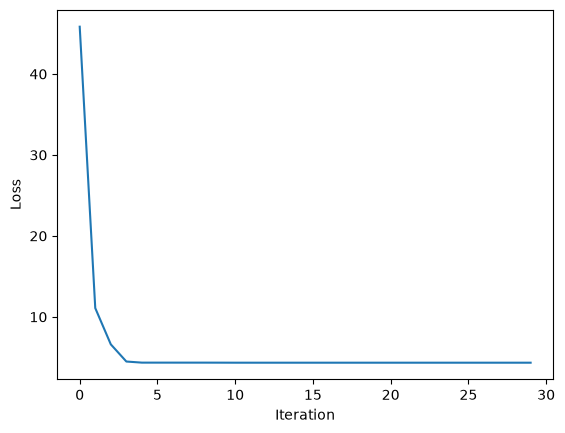

In [16]:
plt.figure()
plt.plot([l.item() for l in loss])
plt.xlabel("Iteration")
plt.ylabel("Loss")

msg = (
    f"Iter {i+1:3d}/{Niter:3d} "
    f"Loss={loss.item():8.3f} "
    f"mean={model.mean.constant.item():8.4f} "
    f"outputscale={model.covar.outputscale.item():8.4f} "
    f"lengthscale={model.covar.base_kernel.lengthscale.item():8.4f}"
)

print(msg)

print(
    model.mean.constant.item(),
    model.covar.raw_outputscale.item(),
    model.covar.base_kernel.raw_lengthscale.item()
)

In [17]:
# Get into evaluation (predictive posterior) mode
#model.eval()
#model.likelihood.eval()

In [18]:
# get inpaint model and inpainted data
with torch.no_grad():
    inp_y, mdl = model.inpaint(inp_flags, y_offset=y_offset, to_complex=True)
inp_y = inp_y.reshape(-1, Ntimes, Nfreqs)

# inp_y.reshape(-1, 2, 3) =》 把 GP 内部的 batch 形式重新恢复成（ Nbls,Ntimes, Nfreq)形式 
#=>之后也可再自行加1维,变成 # shape = (Npol, Nbls, Ntimes, Nfreq)
#                                 = (1,    1,    2,      3)

print(mdl)
mdl = mdl.reshape(-1, Ntimes, Nfreqs)  #同理
#mdl inpaint 所有点
#inp_y inpaint flag点
#return inp_y, mdl, model, y_offset

tensor([[-55.5036+113.9283j, -53.3273+113.3705j, -51.1484+112.7628j,
          ...,  33.9410-23.4382j,  32.9248-24.0226j,
          31.8909-24.5710j],
        [-52.6937+112.0524j, -50.7807+111.7346j, -48.8534+111.3556j,
          ...,  33.5868-25.2221j,  32.5532-26.0680j,
          31.4981-26.8991j],
        [-55.2135+113.5021j, -52.7679+113.0117j, -50.3238+112.4682j,
          ...,  33.7885-25.3129j,  32.7586-26.0836j,
          31.7050-26.8320j],
        ...,
        [-28.9683+109.5836j, -26.7935+108.9841j, -24.6167+108.3325j,
          ...,  29.4051-26.7828j,  28.1839-27.5906j,
          26.9433-28.3789j],
        [-24.9410+109.5250j, -22.8699+108.8039j, -20.7993+108.0301j,
          ...,  30.5833-28.1140j,  29.4454-28.7287j,
          28.2897-29.3092j],
        [-23.5588+110.4515j, -21.3908+109.5363j, -19.2258+108.5772j,
          ...,  32.0077-26.7601j,  31.1608-27.5300j,
          30.3078-28.2804j]], dtype=torch.complex128)


In [20]:
import numpy as np

def flags_to_fchans(flag_array):
    """
    Convert a 1D boolean flag array into a list of
    contiguous flagged channel ranges.

    Parameters
    ----------
    flag_array : ndarray of bool, shape (Nfreq,)

    Returns
    -------
    fchans : list of tuple
        Example:
        [(38, 41), (61, 61), (80, 80), (132, 155)]
    """
    idx = np.where(flag_array)[0]

    if len(idx) == 0:
        return []

    fchans = []
    start = prev = idx[0]

    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            fchans.append((start, prev))
            start = prev = i

    fchans.append((start, prev))

    return fchans





[(38, 41), (61, 61), (81, 81), (131, 133), (135, 135), (137, 150), (152, 152), (175, 177), (180, 181), (187, 187), (191, 191), (194, 195), (201, 201), (203, 203), (207, 213), (221, 227), (229, 229), (232, 232), (238, 238), (244, 244), (276, 276), (279, 280), (286, 286), (288, 288), (293, 294), (302, 302), (312, 313), (315, 315), (320, 321), (338, 338), (340, 340), (408, 409), (411, 411), (416, 416), (419, 419), (423, 423), (451, 451), (500, 501), (503, 503), (514, 521), (523, 523), (543, 543), (551, 553), (566, 568), (570, 575), (577, 577), (582, 584), (599, 599)]


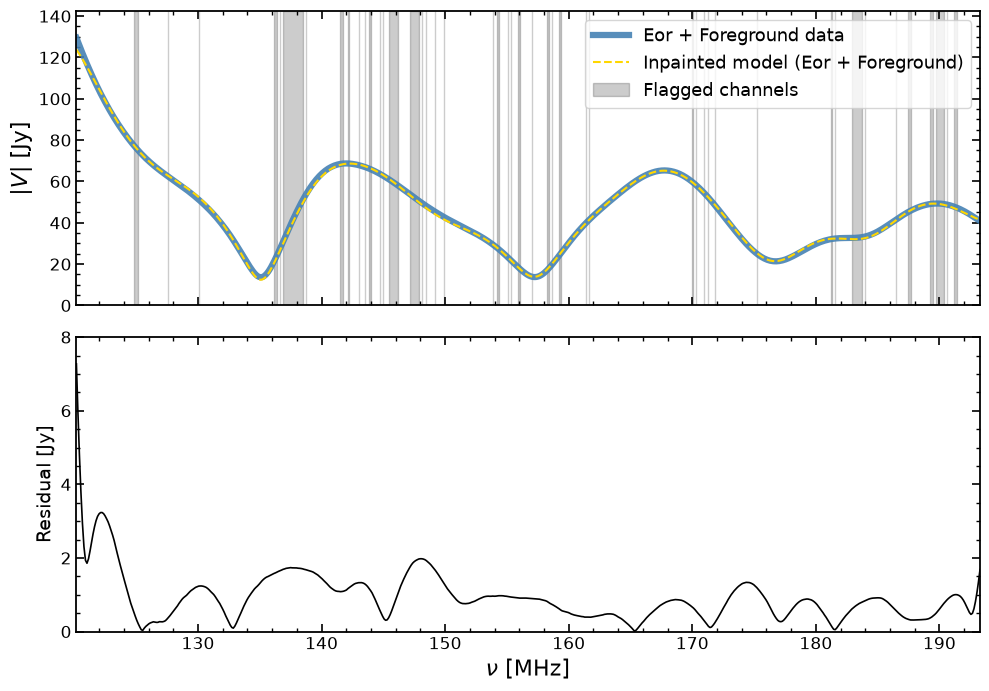

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# x range (MHz)
xlim = (freqs.min(), freqs.max())

# ==========================================
# Top panel
# ==========================================
ax = axes[0]

# Tick style
ax.tick_params(axis='both', which='major',
               labelsize=12, direction='in',
               length=6, width=1.2,
               top=True, right=True)

ax.tick_params(axis='both', which='minor',
               direction='in',
               length=3, width=1.0,
               top=True, right=True)

ax.minorticks_on()

# Flagged channels
fchans = flags_to_fchans(flags[0, 0, 1, :])
print(fchans)

for fc in fchans:
    ax.axvspan(
        freqs[fc[0]],
        freqs[fc[1]],
        color='k',
        alpha=0.2
    )

# Original data
vis = np.abs(eor_fg_data[0, 0, 1, :])

p0, = ax.plot(
    freqs,
    vis,
    lw=4.5,
    color='steelblue',
    alpha=0.9
)

# Inpainted model
mdl_abs = np.abs(mdl[0, 1, :])

p1, = ax.plot(
    freqs,
    mdl_abs,
    lw=1.5,
    color='gold',
    ls='--'
)

# Legend patch
r = plt.Rectangle((0, 0), 0, 0, color='k', alpha=0.2)

ax.legend(
    [p0, p1, r],
    ['Eor + Foreground data',
     'Inpainted model (Eor + Foreground)',
     'Flagged channels'],
    fontsize=13
)

# Automatic axis limits
ax.set_xlim(xlim)
ax.set_ylim(0, 1.1 * max(vis.max(), mdl_abs.max()))

ax.set_ylabel(r'$|V|$ [Jy]', fontsize=16)

# Thicker frame
for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# ==========================================
# Bottom panel
# ==========================================
ax = axes[1]

ax.tick_params(axis='both', which='major',
               labelsize=12, direction='in',
               length=6, width=1.2,
               top=True, right=True)

ax.tick_params(axis='both', which='minor',
               direction='in',
               length=3, width=1.0,
               top=True, right=True)

ax.minorticks_on()

# Residual
resid = mdl[0, 1, :] - eor_fg_data[0, 0, 1, :]
resid_abs = np.abs(resid)  #/abs(mdl[0, 1, :])

ax.plot(
    freqs,
    resid_abs,
    color='k',
    lw=1.2
)

# Automatic limits
ax.set_xlim(xlim)
ax.set_ylim(0, 1.1 * resid_abs.max())

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel(r'Residual [Jy]', fontsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

plt.tight_layout()
plt.show()

In [ ]:
 mdl[0, 1, :]

In [ ]:
eor_fg_data[0, 0, 1, :]